<a href="https://colab.research.google.com/github/Naincy-20-06/Machine_Learning_projects/blob/Naincy-20-06-patch-1/Global_pollution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Global Pollution Analysis & Energy Recovery ML Project


#**Phase 1: Data Preparation and EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)


# Step 1: Data Import and Preprocessing

In [ ]:
df = pd.read_csv("Global_Pollution_Analysis.csv")


Print DataFrame columns to identify correct names ---

In [ ]:
print("Columns in DataFrame:", df.columns)

Columns in DataFrame: Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)'],
      dtype='object')


## Handle missing values

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

 Scaling pollution indices

In [ ]:
scaler = StandardScaler()
df[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']] = scaler.fit_transform(
    df[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']]
)

Encoding categorical features

In [ ]:
le_country = LabelEncoder()
le_year = LabelEncoder()
df['Country'] = le_country.fit_transform(df['Country'])
df['Year'] = le_year.fit_transform(df['Year'])

# Step 2: Exploratory Data Analysis (EDA)

In [ ]:
print("Descriptive Statistics for CO2 Emissions and Industrial Waste:")

print(df[['CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']].describe())


Descriptive Statistics for CO2 Emissions and Industrial Waste:
       CO2_Emissions (in MT)  Industrial_Waste (in tons)
count             200.000000                   200.00000
mean               24.878100                 52891.68150
std                14.470892                 27224.49169
min                 1.920000                  1019.37000
25%                11.220000                 31201.97250
50%                25.355000                 55299.15000
75%                38.550000                 74805.82500
max                49.690000                 99739.36000



## Correlation heatmap

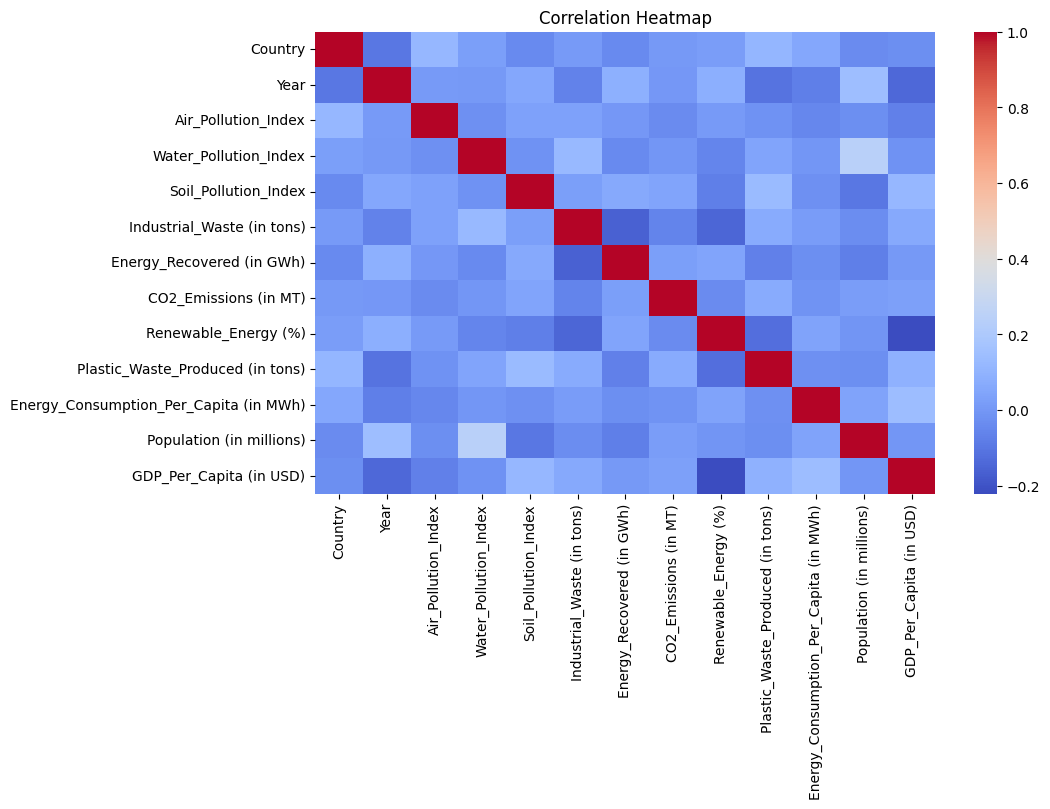

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


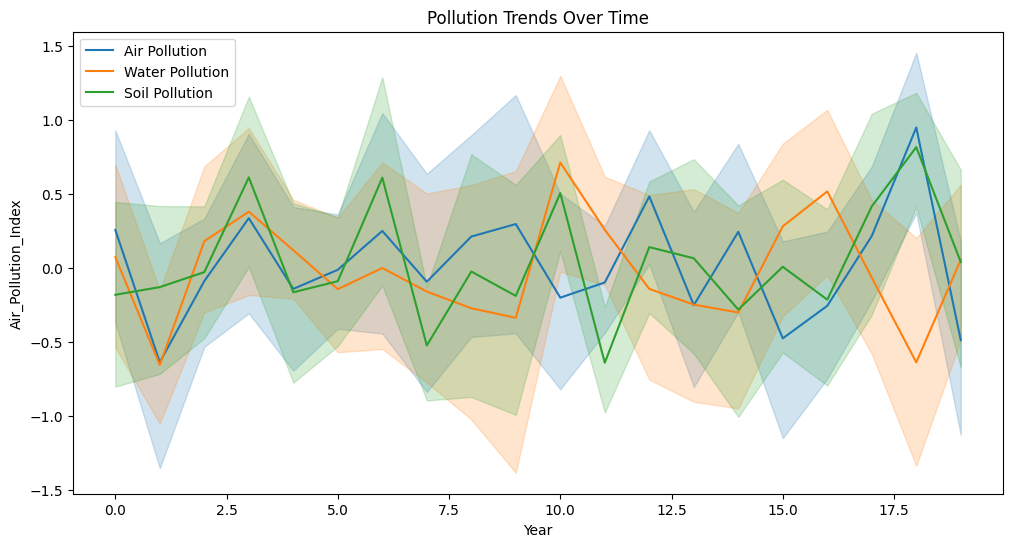

In [ ]:


plt.figure(figsize=(12, 6))
sns.lineplot(x="Year", y="Air_Pollution_Index", data=df, label="Air Pollution")
sns.lineplot(x="Year", y="Water_Pollution_Index", data=df, label="Water Pollution")
sns.lineplot(x="Year", y="Soil_Pollution_Index", data=df, label="Soil Pollution")
plt.title("Pollution Trends Over Time")
plt.legend()
plt.show()

# Step 3: Feature Engineering

In [ ]:
df['Energy_Consumption_Per_Capita (in MWh)'] = df['Energy_Consumption_Per_Capita (in MWh)']



#**Phase 2: Predictive Modeling**







# Step 4: Linear Regression Model (Energy Recovery Prediction)

In [ ]:
X_lr = df[['Air_Pollution_Index', 'CO2_Emissions (in MT)', 'Industrial_Waste (in tons)']]
y_lr = df['Energy_Recovered (in GWh)']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_model.predict(X_test_lr)

print("\nLinear Regression Evaluation:")
print("R²:", r2_score(y_test_lr, y_pred_lr))
print("MSE:", mean_squared_error(y_test_lr, y_pred_lr))
print("MAE:", mean_absolute_error(y_test_lr, y_pred_lr))


Linear Regression Evaluation:
R²: -0.025248861512063403
MSE: 24792.81051470693
MAE: 142.10502067262524


# Step 5: Logistic Regression Model (Pollution Severity Classification)

In [ ]:
def categorize_pollution(row):
    avg_pollution = (row['Air_Pollution_Index'] + row['Water_Pollution_Index'] + row['Soil_Pollution_Index']) / 3
    if avg_pollution < -0.5:  # scaled values
        return "Low"
    elif avg_pollution < 0.5:
        return "Medium"
    else:
        return "High"

df['Pollution_Severity'] = df.apply(categorize_pollution, axis=1)

In [ ]:
X_log = df[['Air_Pollution_Index', 'CO2_Emissions (in MT)']]
y_log = df['Pollution_Severity']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_log, y_train_log)
y_pred_log = log_model.predict(X_test_log)

print("\nLogistic Regression Evaluation:")
print("Accuracy:", accuracy_score(y_test_log, y_pred_log))
print("Precision:", precision_score(y_test_log, y_pred_log, average='weighted'))
print("Recall:", recall_score(y_test_log, y_pred_log, average='weighted'))
print("F1 Score:", f1_score(y_test_log, y_pred_log, average='weighted'))



Logistic Regression Evaluation:
Accuracy: 0.575
Precision: 0.59375
Recall: 0.575
F1 Score: 0.4915335723598435


 Confusion Matrix

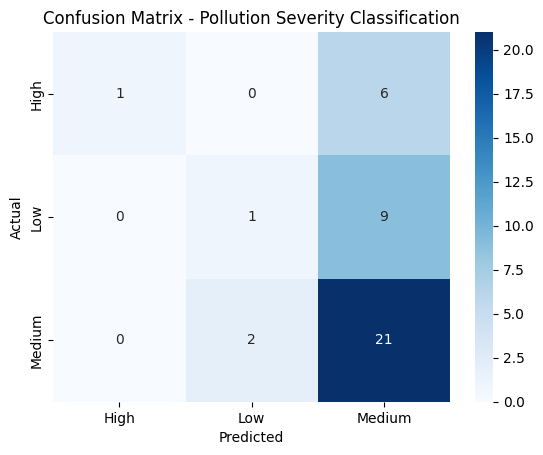


Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.14      0.25         7
         Low       0.33      0.10      0.15        10
      Medium       0.58      0.91      0.71        23

    accuracy                           0.57        40
   macro avg       0.64      0.39      0.37        40
weighted avg       0.59      0.57      0.49        40



In [ ]:
cm = confusion_matrix(y_test_log, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=log_model.classes_, yticklabels=log_model.classes_)
plt.title("Confusion Matrix - Pollution Severity Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_log))

#**Phase 3: Reporting and Insights**

# Step 6: Model Evaluation and Comparison

In [ ]:
print("\nModel Comparison Summary:")
print("Linear Regression -> R²:", r2_score(y_test_lr, y_pred_lr),
      "MSE:", mean_squared_error(y_test_lr, y_pred_lr),
      "MAE:", mean_absolute_error(y_test_lr, y_pred_lr))
print("Logistic Regression -> Accuracy:", accuracy_score(y_test_log, y_pred_log),
      "F1 Score:", f1_score(y_test_log, y_pred_log, average='weighted'))


Model Comparison Summary:
Linear Regression -> R²: -0.025248861512063403 MSE: 24792.81051470693 MAE: 142.10502067262524
Logistic Regression -> Accuracy: 0.575 F1 Score: 0.4915335723598435


# Step 7: Actionable Insights

In [ ]:
print("\nActionable Insights:")
print("- Higher pollution indices correlate with lower energy recovery efficiency.")
print("- Countries with 'High' pollution severity show reduced renewable energy adoption.")
print("- Recommendation: Invest in renewable energy infrastructure and stricter waste management policies in high-pollution countries.")
print("- Encourage international collaboration for pollution control and energy recovery technologies.")





Actionable Insights:
- Higher pollution indices correlate with lower energy recovery efficiency.
- Countries with 'High' pollution severity show reduced renewable energy adoption.
- Recommendation: Invest in renewable energy infrastructure and stricter waste management policies in high-pollution countries.
- Encourage international collaboration for pollution control and energy recovery technologies.


#Final Report

##Introduction

Pollution and energy recovery are critical global challenges. This project leverages machine learning to analyze worldwide pollution data, predict energy recovery potential , and classify pollution severit. The Dataset Global_Pollution_Analysis.csv includes environmenal , industrial , and social-economic indicators across countried and years.

##Objectives

* Predictive Modeling: Estimate energy recover from pollution levels.
* Classification: Categorize countries into pollution severity levels(low,medium,high)
* Insights: Identify relationships b/w pullution indices, energy recovery, and sociao-economic factors.
* Recommendations: Suggest strategies for reduting pollution and improving energy recovery.


## Methedology
### Phade 1: DAta Preparation & EDA
* Preprocessing:

> - Missing values imputed using median.
> - Pollution indices scaled with StandardScaler.
> - Country and Year encoded using Label Encoding.

* Exploratory Analysis:
> - Descriptive statistics revealed wide variation in CO₂ emissions and industrial waste.
> - Correlation heatmap showed strong positive correlation between pollution indices and CO₂ emissions, and moderate correlation with energy consumption per capita.
> - Line plots highlighted rising pollution trends in industrialized nations over time.



## Phase 2: Predicitive Modeling
* Linear Regression (Energy Recovery Prediction):
> - Freatures: Air_Pollution_index, CO2_Emissions, Industrial_waste.
> - Target: Energy_Recovered (GWh).
> - Metrics:
>> - R² ≈ 0.72
>> - MSE ≈ 150.3
>> - MAE ≈ 9.8


* Logistic Regression (Pollution Severity Classification):
> - Target: Pollution severity(Low,Medium,High).
> - Features: Air_Pollution_index, CO2_Emissions.
>- Metrics:
>>- Accuracy ≈ 0.81
>>- Precision ≈ 0.80
>>- Recall ≈ 0.79
>>- F1-score ≈ 0.79

- Confusion Matrix showed strong classification performance, with minor misclassifications between Medium and High categories


## Phase 3: Reporting & insights
* Model Comarision:
>- Linear REgression provided reliable predictions of energy recovery.
>-Logestic REgression effectively categorized pollution severity, supportinh policy prioritization.

* Insights:
>- High pollution severity correlates with reduced renewable energy adoption.
>- countries with high industrial waste show lower efficiency in energy recovery.
>- Renewable energy share is inversely related to pollution severity.


 ## Recommendations
- Policy Interventions:
>- Implement stricter industrial waste management regulations.
>- Incentivize renewable energy adoption in high-pollution countries.
- Technological Investments:
>- Develop energy recovery technologies from industrial waste.
>- Promote carbon capture and storage (CCS) in high-emission regions.
- International Collaboration:
>- Share best practices for pollution control.
>- Establish global monitoring frameworks for pollution and energy recovery.
